In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Configure matplotlib for better performance with large datasets
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['lines.linewidth'] = 0.5

In [2]:
# Function to calculate fitness with hardcoded equations
def calculate_fitness(equations1, equations2, registro):
    """
    Calculate fitness based on the system of equations.
    fitness = sum(weights[i] * equations[i](digits[i])) for i in range(len(digits))
    
    Modify the weights and equations lists below as needed for your experiments.
    digits[0] = x1 (least significant digit, rightmost)
    digits[n-1] = xn (most significant digit, leftmost)
    """
            
    # Calculate fitness by iterating over the 3 lists
    fitness1, fitness2 = 0, 0
    
    for equation in equations1:
        fitness1 += equation(registro)

    for equation in equations2:
        fitness2 += equation(registro)
    
    return fitness1, fitness2

In [3]:
# ============================================================================
# FRONTEIRA DE PARETO - Problema de Maximização Bi-Objetivo
# ============================================================================

def find_pareto_front(df):
    """
    Encontra a fronteira de Pareto para um problema de maximização bi-objetivo.
    
    Um ponto A domina um ponto B se:
    - A.fitness1 >= B.fitness1 AND A.fitness2 >= B.fitness2
    - E pelo menos uma das desigualdades é estrita (>)
    
    A fronteira de Pareto contém todos os pontos não-dominados.
    
    Algoritmo eficiente:
    1. Ordenar pontos por fitness1 (decrescente)
    2. Iterar mantendo o máximo de fitness2 visto até agora
    3. Um ponto está na fronteira se seu fitness2 > máximo visto
    
    Args:
        df: DataFrame com colunas ['registro', 'fitness1', 'fitness2']
        
    Returns:
        DataFrame contendo apenas os pontos da fronteira de Pareto
    """
    print("Encontrando fronteira de Pareto...")
    print(f"Total de pontos no espaço de busca: {len(df):,}")
    
    # Criar cópia para não modificar o dataframe original
    df_sorted = df.copy()
    
    # Ordenar por fitness1 (decrescente, pois queremos maximizar)
    # Em caso de empate em fitness1, ordenar por fitness2 (decrescente)
    df_sorted = df_sorted.sort_values(by=['fitness1', 'fitness2'], 
                                       ascending=[False, False])
    
    # Lista para armazenar índices dos pontos não-dominados
    pareto_indices = []
    
    # Máximo de fitness2 visto até agora
    max_fitness2 = float('-inf')
    
    # Iterar pelos pontos ordenados
    for idx, row in df_sorted.iterrows():
        # Se fitness2 do ponto atual é maior que o máximo visto,
        # então este ponto não é dominado
        if row['fitness2'] > max_fitness2:
            pareto_indices.append(idx)
            max_fitness2 = row['fitness2']
    
    # Extrair os pontos da fronteira de Pareto
    pareto_front = df.loc[pareto_indices].copy()
    
    # Ordenar a fronteira por fitness1 para melhor visualização
    pareto_front = pareto_front.sort_values(by='fitness1', ascending=False)
    
    print(f"✅ Fronteira de Pareto encontrada!")
    print(f"Fronteira de Pareto contém {len(pareto_front):,} pontos.")
    print(f"Isso representa {100 * len(pareto_front) / len(df):.4f}% do espaço de busca.")
    
    return pareto_front

In [4]:
def display_pareto_front(df, pareto_df):

        # Gráfico de dispersão da fronteira de Pareto
        fig, ax = plt.subplots(figsize=(12, 8))

        # Plotar a fronteira de Pareto
        ax.scatter(pareto_df['fitness1'], pareto_df['fitness2'], 
                c='red', s=50, alpha=0.7, edgecolors='darkred', 
                linewidth=1.5, label='Fronteira de Pareto', zorder=3)

        # Conectar os pontos para melhor visualização
        ax.plot(pareto_df['fitness1'], pareto_df['fitness2'], 
                'r--', alpha=0.4, linewidth=1, zorder=2)

        # Configurações do gráfico
        ax.set_xlabel('Fitness1 (f1)', fontsize=13, fontweight='bold')
        ax.set_ylabel('Fitness2 (f2)', fontsize=13, fontweight='bold')
        ax.set_title(f'Fronteira de Pareto Global Verdadeira\n({len(pareto_df):,} pontos não-dominados)', 
                fontsize=15, fontweight='bold', pad=20)
        ax.legend(fontsize=11, loc='best')
        ax.grid(True, alpha=0.3, linestyle='--')

        # Adicionar anotações para os pontos extremos
        # Ponto com maior fitness1
        max_f1_point = pareto_df.iloc[0]
        ax.annotate(f'Max f1\n({max_f1_point["fitness1"]:.2f}, {max_f1_point["fitness2"]:.2f})',
                xy=(max_f1_point['fitness1'], max_f1_point['fitness2']),
                xytext=(10, -20), textcoords='offset points',
                fontsize=9, color='darkred',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

        # Ponto com maior fitness2
        max_f2_point = pareto_df.iloc[-1]
        ax.annotate(f'Max f2\n({max_f2_point["fitness1"]:.2f}, {max_f2_point["fitness2"]:.2f})',
                xy=(max_f2_point['fitness1'], max_f2_point['fitness2']),
                xytext=(10, 20), textcoords='offset points',
                fontsize=9, color='darkred',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

        plt.tight_layout()
        plt.show()

        print("\n✅ Visualização concluída!")


        # ============================================================================
        # GRÁFICO ADICIONAL: Fronteira de Pareto no contexto de todos os pontos
        # ============================================================================

        # Plotar todos os pontos e destacar a fronteira de Pareto
        fig, ax = plt.subplots(figsize=(14, 8))

        # Subsampling para todos os pontos (para não sobrecarregar o gráfico)
        sample_size = min(50000, len(df))  # Máximo de 50k pontos
        df_sample = df.sample(n=sample_size, random_state=42)

        # Plotar todos os pontos (amostra) em cinza
        ax.scatter(df_sample['fitness1'], df_sample['fitness2'], 
                c='lightgray', s=10, alpha=0.3, 
                label=f'Todos os pontos (amostra de {sample_size:,})', zorder=1)

        # Plotar a fronteira de Pareto em destaque
        ax.scatter(pareto_df['fitness1'], pareto_df['fitness2'], 
                c='red', s=80, alpha=0.9, edgecolors='darkred', 
                linewidth=1.5, label='Fronteira de Pareto', zorder=3)

        # Conectar os pontos da fronteira
        ax.plot(pareto_df['fitness1'], pareto_df['fitness2'], 
                'r-', alpha=0.6, linewidth=2, zorder=2)

        # Configurações do gráfico
        ax.set_xlabel('Fitness1 (f1)', fontsize=13, fontweight='bold')
        ax.set_ylabel('Fitness2 (f2)', fontsize=13, fontweight='bold')
        ax.set_title(f'Fronteira de Pareto no Espaço de Objetivos\n(Problema de Maximização Bi-Objetivo)', 
                fontsize=15, fontweight='bold', pad=20)
        ax.legend(fontsize=11, loc='best')
        ax.grid(True, alpha=0.3, linestyle='--')

        plt.tight_layout()
        plt.show()



In [5]:
def display_fitness_landscape_with_pareto(df, pareto_df=None):
    '''
    Plots comprehensive fitness landscape with Pareto front overlay
    '''
    
    def add_pareto_markers(ax, pareto_df, y_col, marker_color, marker_style='D'):
        """Helper function to add Pareto markers and vertical lines"""
        # Add vertical lines at key Pareto positions
        pareto_sorted = pareto_df.sort_values('registro')
        positions = [0, len(pareto_sorted)//4, len(pareto_sorted)//2, 
                     3*len(pareto_sorted)//4, -1]
        for i in positions:
            ax.axvline(x=pareto_sorted.iloc[i]['registro'], color='red', 
                      alpha=0.3, linewidth=1.5, linestyle='--', zorder=1)
        
        # Add scatter points
        ax.scatter(pareto_df['registro'], pareto_df[y_col], 
                  c=marker_color, s=40 if marker_style=='D' else 50, 
                  alpha=0.9 if marker_style=='D' else 0.95,
                  edgecolors='darkred' if marker_color=='red' else ('black' if marker_color=='darkgreen' else 'darkorange'),
                  linewidth=1.5 if marker_style=='D' else 2,
                  label=f'Pareto Front ({len(pareto_df):,})', 
                  zorder=5, marker=marker_style)
    
    # Configuration for each subplot
    plot_configs = [
        {
            'y_col': 'fitness1',
            'fill_color': 'steelblue',
            'edge_color': 'darkblue',
            'marker_color': 'red',
            'marker_style': 'D',
            'ylabel': 'Fitness1',
            'title': 'Fitness1 Landscape com Pareto Front'
        },
        {
            'y_col': 'fitness2',
            'fill_color': 'coral',
            'edge_color': 'darkred',
            'marker_color': 'darkgreen',
            'marker_style': 'D',
            'ylabel': 'Fitness2',
            'title': 'Fitness2 Landscape com Pareto Front'
        }
    ]
    
    fig, axes = plt.subplots(3, 1, figsize=(16, 14))
    
    # Plot first two subplots (fitness1 and fitness2)
    for ax, config in zip(axes[:2], plot_configs):
        ax.fill_between(df['registro'], df[config['y_col']], alpha=0.5,
                       color=config['fill_color'], edgecolor=config['edge_color'],
                       linewidth=0.5, label='Todos os pontos')
        
        if pareto_df is not None:
            add_pareto_markers(ax, pareto_df, config['y_col'], 
                             config['marker_color'], config['marker_style'])
        
        ax.set_xlabel('Registro (x)', fontsize=12, fontweight='bold')
        ax.set_ylabel(config['ylabel'], fontsize=12, fontweight='bold')
        ax.set_title(config['title'], fontsize=14, fontweight='bold')
        ax.legend(fontsize=10, loc='best', framealpha=0.9)
        ax.grid(True, alpha=0.3)
    
    # Third subplot (comparison)
    ax = axes[2]
    for col, color, alpha, lw, label in [
        ('fitness_full', 'purple', 0.6, 1, 'Fitness Full (todos)'),
        ('fitness1', 'steelblue', 0.5, 0.8, 'Fitness1 (todos)'),
        ('fitness2', 'coral', 0.5, 0.8, 'Fitness2 (todos)')
    ]:
        ax.plot(df['registro'], df[col], alpha=alpha, color=color, 
               linewidth=lw, label=label)
    
    if pareto_df is not None:
        add_pareto_markers(ax, pareto_df, 'fitness_full', 'gold', '*')
    
    ax.set_xlabel('Registro (x)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Fitness', fontsize=12, fontweight='bold')
    ax.set_title('Comparação Completa: Fitness Full vs Fitness1 vs Fitness2',
                fontsize=14, fontweight='bold')
    ax.legend(fontsize=9, loc='best', framealpha=0.9, ncol=2)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [10]:
equations1 = [
    lambda x: (x/500000)**2 / 20,
    lambda x: 7 * np.cos(x/10000000),
    lambda x: 4 * np.cos(x/4000000),
    lambda x: 5 * np.cos(x/1000000),
    lambda x: 5 * np.cos(x/500000),
    lambda x: 4 * np.sin(x/100000),
    lambda x: 3 * np.cos(x/25000),
    lambda x: 2 * np.cos(x/4000),
    lambda x:     np.sin(x/2000),
    lambda x: np.maximum(0, 3 * np.cos(2.3+ (x/10000))),
    lambda x: np.maximum(0, 3 * np.sin(1  + (x/10000))),
    lambda x: 5,
]

equations2 = [
    lambda x: (x/420000)**2 / 15,
    lambda x: 7 * np.sin(x/10000000),
    lambda x: 2 * np.sin(x/4000000),
    lambda x: 2 * np.sin(x/2000000),
    lambda x: 2 * np.sin(x/1000000),
    lambda x: 2 * np.cos(x/300000),
    lambda x: 2 * np.cos(x/50000),
    lambda x:     np.sin(x/20000),
    lambda x:     np.cos(x/8000),
    lambda x: np.minimum(0, 3 * np.cos(2.3+ (x/10000))),
    lambda x: np.minimum(0, 3 * np.sin(1  + (x/10000))),
    lambda x: 5,
]

total_records = 5000000

5000000
[      0       1       2 ... 4999997 4999998 4999999]
 


100%|██████████| 5000000/5000000 [03:33<00:00, 23413.70it/s]


Encontrando fronteira de Pareto...
Total de pontos no espaço de busca: 5,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 22,125 pontos.
Isso representa 0.4425% do espaço de busca.


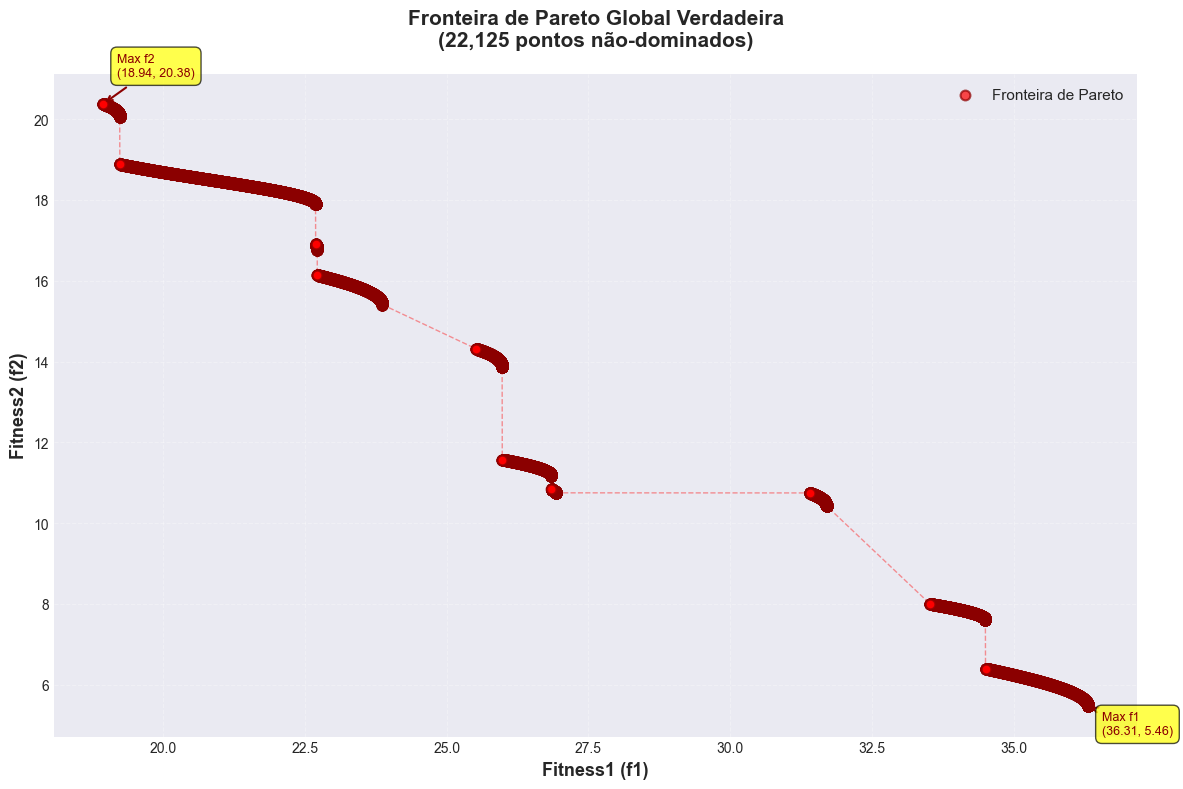


✅ Visualização concluída!


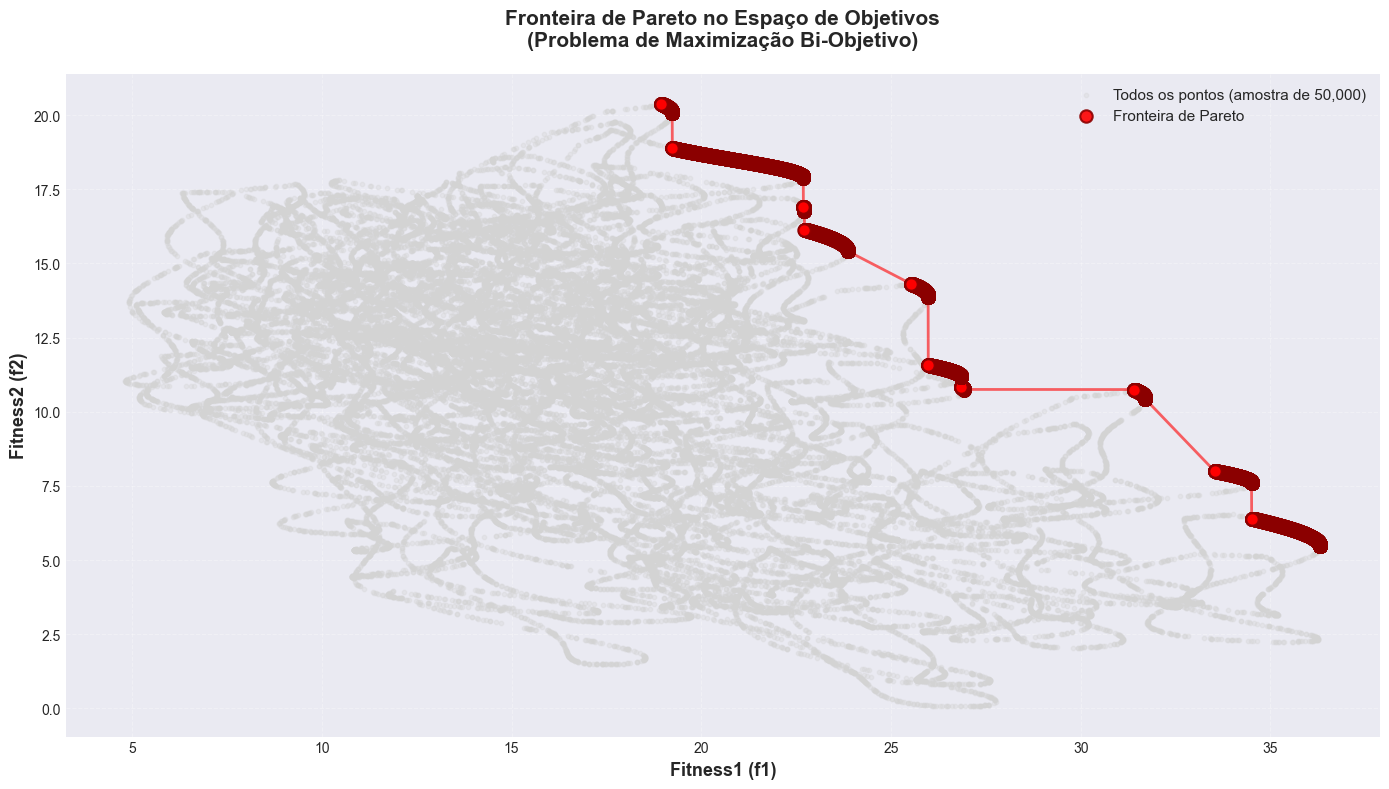

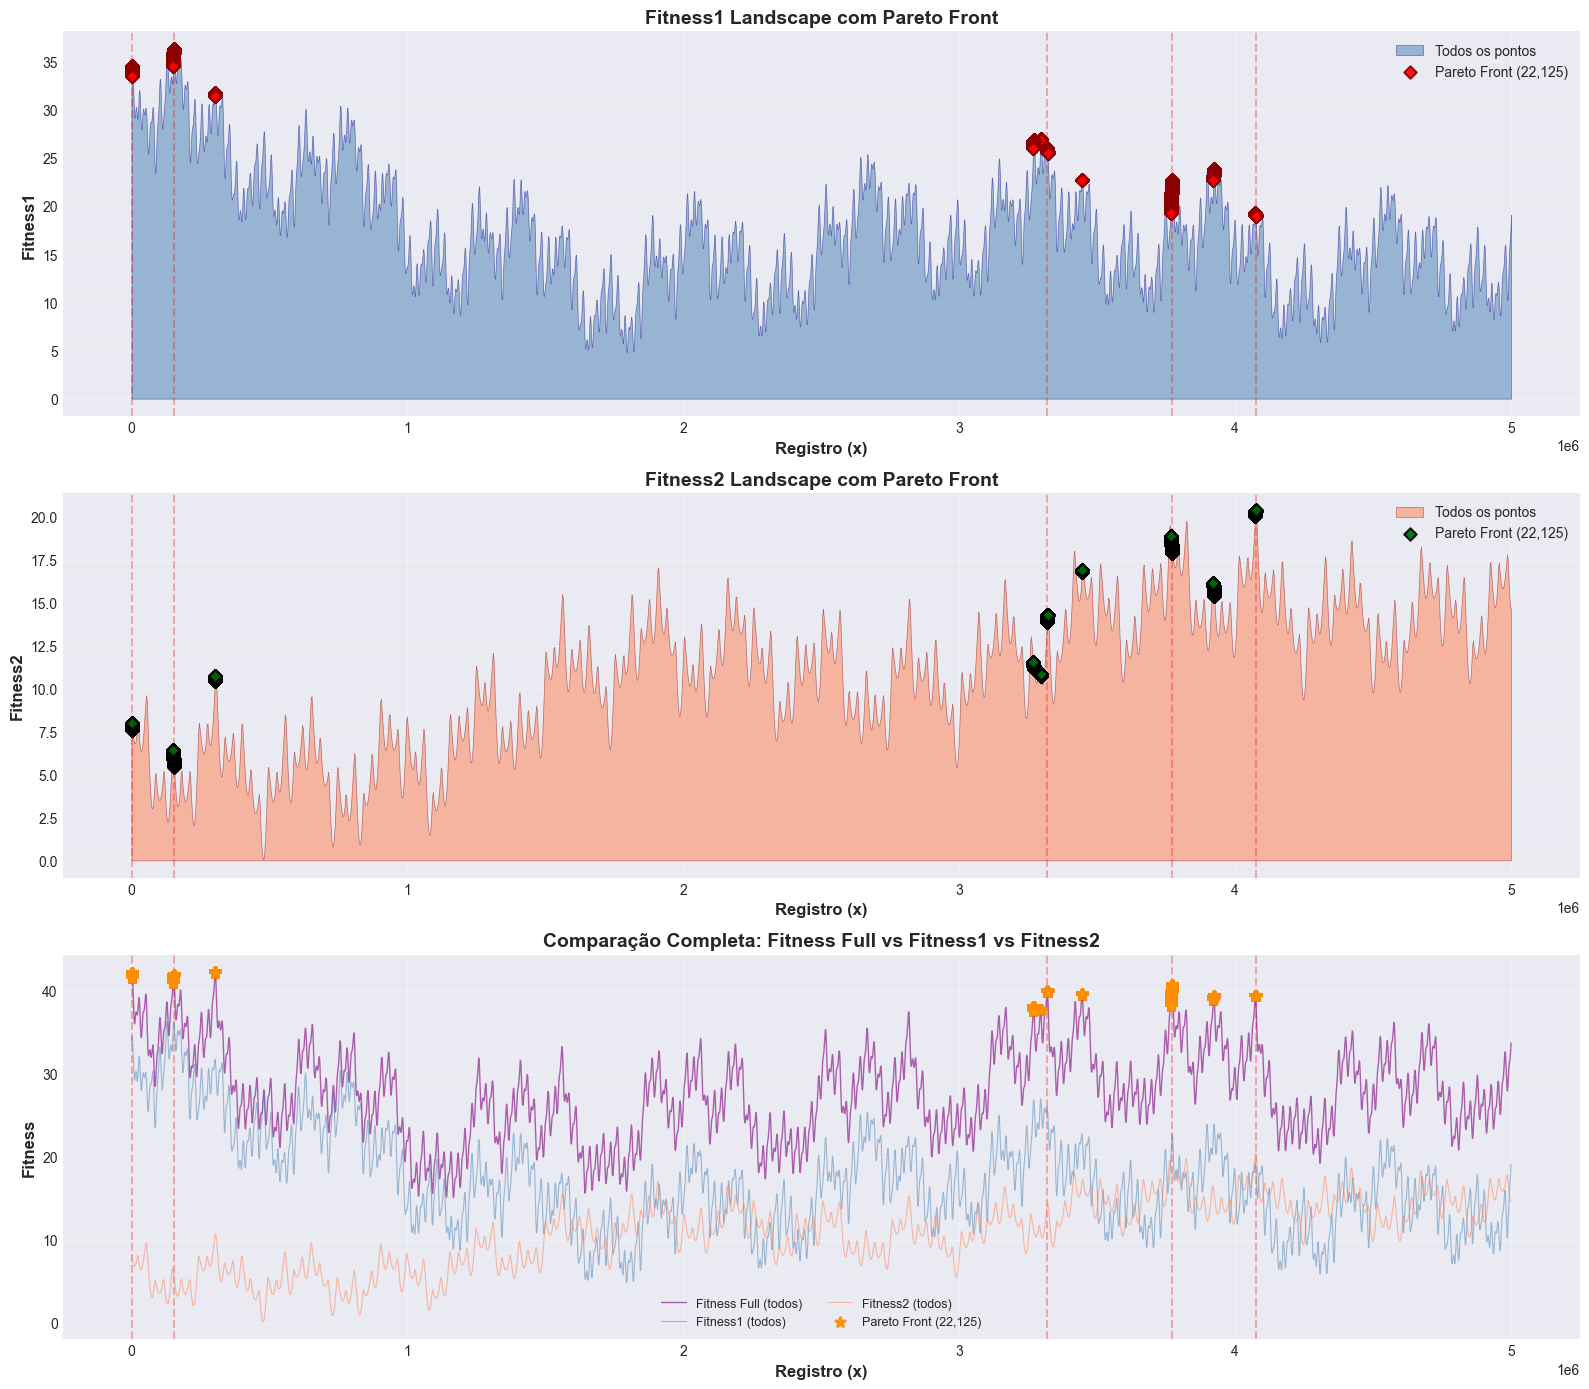

In [11]:
tamanho = len(str(total_records))-1
registros = np.arange(0, total_records, dtype=np.int32)
print(len(registros))
print(registros)
print(' ')


# Create the dataset with progress bar
data = []
for registro in tqdm(registros):
    fitness1, fitness2 = calculate_fitness(equations1, equations2, registro)        
    row = [registro, fitness1, fitness2]
    data.append(row)

# Create DataFrame
columns = ['registro', 'fitness1', 'fitness2'] 
df = pd.DataFrame(data, columns=columns)
df['fitness_full'] = df['fitness1'] + df['fitness2']


# Encontrar a fronteira de Pareto no dataframe df existente
pareto_df = find_pareto_front(df)
display_pareto_front(df, pareto_df)
display_fitness_landscape_with_pareto(df, pareto_df)
